In [1]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import from_bounds, transform as window_transform
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
)
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# =========================
# User inputs (edit these)
# =========================
gpkg_path = "TA64_LA_Wildfires/Closest_to_Sentinel-1_t064a_CA_Perimeters_NIFC_FIRIS_20250203T072944.gpkg"              # polygons in a GeoPackage
gpkg_layer = None                      # e.g. "my_layer" (or None to use default)
eval_bounds_geojson_path = "TA64_LA_Wildfires/Closest_to_Sentinel-1_t064a_CA_Perimeters_NIFC_FIRIS_20250203T072944EvalBounds.geojson"   # has property "mission"

target_raster_paths = [
    "TA64_LA_Wildfires/others/20250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_linear.wprobs.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.wprobs.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_nn.wprobs.tif",
    "TA64_LA_Wildfires/others/geoisce_nn_220250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/others/geoisce_sinc_20250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/20250109_GSLC_30m_resampled.wprobs.geo.tif"
    # "TA64_LA_Wildfires/others/20250109.wprobs.geo.tif"
]

thresholds = np.round(np.arange(0.50, 0.90 + 1e-9, 0.05), 2)
all_touched = False                    # True if you want "all_touched" rasterization
# save_rasterized_path = f"{os.path.splitext(target_raster_path)[0]}_validation.tif"            # e.g. "labels_on_target_grid.tif" or None

# Optional outputs (GeoTIFFs that will open correctly in QGIS)
save_polygon_raster = True
# save_target_clip_path = None     # e.g. "target_clip.tif"

# ---- configurable NoData handling ----
nodata_value = 0               # e.g. 0, 255, -9999, or np.nan
exclude_nodata = False             # if True, nodata pixels are excluded from metrics


# Clip mode:
# "target"   -> full raster
# "gpkg"     -> polygon max extents
# "smallest" -> w
# hichever extent is smaller (raster vs polygons)
# clip_mode = "smallest"
# gpkg_buffer_pixels = 0   # optional buffer (pixels) for "gpkg" or "smallest"


In [3]:
def as_binary(arr, threshold=0.5):
    """Convert numeric array to {0,1}. Non-finite -> 0 (masked later)."""
    arr = np.asarray(arr)
    out = np.zeros(arr.shape, dtype=np.uint8)
    out[np.isfinite(arr) & (arr > threshold)] = 1
    return out


In [4]:
def build_valid_mask(arr, nodata_value=None):
    """
    Build a boolean mask of valid pixels.
    nodata_value can be None, np.nan, or a numeric value.
    """
    mask = np.isfinite(arr)

    if nodata_value is None:
        return mask

    if isinstance(nodata_value, float) and np.isnan(nodata_value):
        mask &= ~np.isnan(arr)
    else:
        mask &= (arr != nodata_value)

    return mask

In [5]:
def compute_binary_confusion(y_true_bin, y_pred_score, thresh, valid_mask):
    """Compute confusion matrix and metrics for binary arrays."""
    y_pred_bin = as_binary(y_pred_score, threshold=thresh)
    y_true = y_true_bin[valid_mask].ravel().astype(np.uint8)
    y_pred = y_pred_bin[valid_mask].ravel().astype(np.uint8)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Critical Success Index (CSI) / Threat Score
    denom = (tp + fp + fn)
    csi = (tp / denom) if denom else np.nan

    metrics = {
        "total_pixels": y_pred.size,
        "total_valid_pixels":np.sum(valid_mask),
        "thresh":thresh,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "csi":float(csi),  
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "fpr": float(fp / (fp + tn)) if (fp + tn) else np.nan,
        "tpr": float(tp / (tp + fn)) if (tp + fn) else np.nan
        }
    return cm, metrics

In [6]:
def rasterize_gdf_to_grid(gdf, out_shape, transform, all_touched=False):
    shapes = ((geom, 1) for geom in gdf.geometry if geom is not None)
    return rasterize(
        shapes=shapes,
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype=np.uint8,
        all_touched=all_touched,
    )

In [7]:
def bounds_area(b):
    minx, miny, maxx, maxy = b
    return max(0.0, maxx - minx) * max(0.0, maxy - miny)


In [8]:

def window_from_geom_bounds(src, bounds):
    """Pixel-aligned window from bounds; clipped to raster extent."""
    minx, miny, maxx, maxy = bounds
    win = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
    win = win.intersection(rasterio.windows.Window(0, 0, src.width, src.height))
    return win.round_offsets().round_lengths()


In [9]:
def plot_confusion_matrix(
    cm,
    class_names=("0 (neg)", "1 (pos)"),
    title="Confusion Matrix",
    cmap="Blues",
    normalize=True,
):
    """
    Confusion matrix layout (labels=[0,1]):
    
                    Predicted
                  0           1
    True 0        TN          FP
    True 1        FN          TP
    """
    cm = np.asarray(cm)

    if normalize:
        cm_norm = cm / cm.sum()
    else:
        cm_norm = None

    # Fixed label map for binary CM
    label_map = np.array([
        ["TN", "FP"],
        ["FN", "TP"]
    ])

    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)

    ax.set_title(title, fontsize=14)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)

    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("DPM2 label")
    ax.set_ylabel("Ground validation")

    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                txt = (
                    f"{label_map[i, j]}\n"
                    f"{cm[i, j]:,}\n"
                    f"({cm_norm[i, j]*100:.1f}%)"
                )
            else:
                txt = (
                    f"{label_map[i, j]}\n"
                    f"{cm[i, j]:,}"
                )

            ax.text(
                j, i, txt,
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=11,
                fontweight="bold" if label_map[i, j] in ("TP", "TN") else "normal",
            )

    plt.tight_layout()
    plt.show()

    return fig, ax

In [10]:
def subset_gdf_to_bounds(gdf, bounds):
    """Fast bbox subset using spatial index if available. bounds in gdf CRS."""
    minx, miny, maxx, maxy = bounds
    try:
        sidx = gdf.sindex
        hits = list(sidx.intersection((minx, miny, maxx, maxy)))
        if not hits:
            return gdf.iloc[0:0].copy()
        return gdf.iloc[hits].copy()
    except Exception:
        return gdf.cx[minx:maxx, miny:maxy].copy()

In [16]:
gdf = gpd.read_file(gpkg_path)
gdf = gdf[gdf.geometry.notnull()].copy()

boxes_gdf = gpd.read_file(eval_bounds_geojson_path)
boxes_gdf = boxes_gdf[boxes_gdf.geometry.notnull()].copy()
if boxes_gdf.empty:
    raise ValueError("No valid eval bounds found in GeoJSON.")
if "mission" not in boxes_gdf.columns:
    raise ValueError("Eval bounds GeoJSON must include a 'mission' property per feature.")

all_results = []   # <-- collect results from all rasters

for target_raster_path in target_raster_paths:
    print("\n======================================")
    print("Processing:", target_raster_path)
    print("======================================")
    # =========================
    # Load vector and align CRS to raster
    # =========================
    
    with rasterio.open(target_raster_path) as dpm2_src:
        if dpm2_src.crs is None:
            raise ValueError("Target raster has no CRS; cannot align polygons.")
        if gdf.crs != dpm2_src.crs:
            gdf = gdf.to_crs(dpm2_src.crs)

        boxes_in_raster = boxes_gdf if boxes_gdf.crs == dpm2_src.crs else boxes_gdf.to_crs(src.crs)
    
        # poly_bounds = tuple(gdf.total_bounds)  # (minx, miny, maxx, maxy)
        
        # =========================
        # Read target + decide evaluation grid (FIXED transform/meta handling)
        # =========================
        gt_in_raster = gdf if gdf.crs == dpm2_src.crs else gdf.to_crs(dpm2_src.crs)

        for _, box_row in boxes_in_raster.iterrows():
            mission = box_row.get("mission", "unknown")
            aoi_geom = box_row.geometry
            aoi_bounds = aoi_geom.bounds  # used only to define a raster window

            # ---- Crop BOTH target raster + GT rasterization to AOI window ----
            win = window_from_geom_bounds(dpm2_src, aoi_bounds)
            if win.width <= 0 or win.height <= 0:
                continue

            target_arr = dpm2_src.read(1, window=win, masked=False)
            grid_transform = dpm2_src.window_transform(win)

            # valid pixels mask (within AOI window)
            valid_mask = build_valid_mask(target_arr, nodata_value=nodata_value) if exclude_nodata else np.ones(target_arr.shape, bool)

            # subset GT polygons by AOI bounds (speed), then rasterize onto AOI grid
            gt_subset = subset_gdf_to_bounds(gt_in_raster, aoi_bounds)

            if gt_subset.empty:
                poly_rast = np.zeros(target_arr.shape, dtype=np.uint8)
            else:
                poly_rast = rasterize_gdf_to_grid(
                    gt_subset,
                    out_shape=target_arr.shape,
                    transform=grid_transform,
                    all_touched=all_touched,
                )
                
    
            # ✅ CRITICAL FIX: update meta to match the window, so saved rasters won't "scale" in QGIS
            meta_win = dpm2_src.meta.copy()
            meta_win.update(
                height=target_arr.shape[0],
                width=target_arr.shape[1],
                transform=grid_transform,
            )

            if save_polygon_raster:
                save_polygon_raster_path = f"{os.path.splitext(target_raster_path)[0]}_{mission}_validation.tif"
                meta_p = meta_win.copy()
                meta_p.update(dtype="uint8", count=1, nodata=0, compress="deflate")
                with rasterio.open(save_polygon_raster_path, "w", **meta_p) as dst:
                    dst.write(poly_rast.astype(np.uint8), 1)
                print("Saved polygon raster:", save_polygon_raster_path)
    
            # =========================
            # Confusion matrix + metrics
            # =========================
            poly_bin = (poly_rast > 0).astype(np.uint8)
            
            valid_mask = build_valid_mask(target_arr, nodata_value=nodata_value) if exclude_nodata else np.ones(target_arr.shape, bool)
            
            # =========================
            # Threshold sweep -> DataFrame
            # =========================
            for thr in thresholds:
                cm, metrics = compute_binary_confusion(poly_bin, target_arr, thr, valid_mask)
                metrics['raster']= target_raster_path
                metrics['mission']= mission
                print(f"Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh {metrics['thresh']}:")
                print(cm)
                # print(f"TN={metrics['tn']} FP={metrics['fp']} FN={metrics['fn']} TP={metrics['tp']}")
                # print(f"Total Pixels       : {metrics['total_pixels']}")
                # print(f"Total Valid Pixels : {metrics['total_valid_pixels']}")
                # print(f"Accuracy           : {metrics['accuracy']:.6f}")
                # print(f"Precision          : {metrics['precision']:.6f}")
                # print(f"Recall             : {metrics['recall']:.6f}")
                # print(f"F1                 : {metrics['f1']:.6f}")
                # print(f"CSI                 : {metrics['csi']:.6f}")
                all_results.append(metrics)
    

df_metrics = pd.DataFrame(all_results)




Processing: TA64_LA_Wildfires/others/20250109.wprobs.geo.tif
Saved polygon raster: TA64_LA_Wildfires/others/20250109.wprobs.geo_CA-LFD-PALISADES-N57B_validation.tif
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.5:
[[33197 63861]
 [ 7552 73550]]
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.55:
[[49448 47610]
 [15077 66025]]
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.6:
[[63540 33518]
 [25244 55858]]
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.65:
[[74952 22106]
 [36698 44404]]
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.7:
[[83525 13533]
 [47711 33391]]
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.75:
[[89353  7705]
 [56940 24162]]
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.8:
[[92946  4112]
 [64241 16861]]
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.85:
[[95047  2011]
 [69624 11478]]
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.

In [15]:
df_metrics.sort_values("f1", ascending=False).groupby("raster").head(1)


,total_pixels,total_valid_pixels,thresh,tn,fp,fn,tp,accuracy,precision,recall,csi,f1,fpr,tpr,raster,mission
56,10384,10384,0.60,7886,705,316,1477,0.901676,0.676902,0.823759,0.591273,0.743145,0.082063,0.823759,TA64_LA_Wildfires/others/geo_20250109_mpy_line...,CA-LAC-LIDIA-N57B
282,10384,10384,0.65,8081,514,436,1353,0.908513,0.724692,0.756288,0.587495,0.740153,0.059802,0.756288,TA64_LA_Wildfires/20250109_GSLC_30m_resampled....,CA-LAC-LIDIA-N57B
192,10384,10384,0.65,8048,542,503,1291,0.899364,0.704310,0.719621,0.552654,0.711883,0.063097,0.719621,TA64_LA_Wildfires/others/geoisce_linear_202501...,CA-LAC-LIDIA-N57B
12,10384,10384,0.65,8007,589,519,1269,0.893297,0.682992,0.709732,0.533866,0.696105,0.068520,0.709732,TA64_LA_Wildfires/others/20250109.wprobs.geo.tif,CA-LAC-LIDIA-N57B
225,178160,178160,0.50,35986,61122,11843,69209,0.590452,0.531025,0.853884,0.486791,0.654821,0.629423,0.853884,TA64_LA_Wildfires/others/geoisce_sinc_20250109...,CA-LFD-PALISADES-N57B
90,178160,178160,0.50,36838,60238,13400,67684,0.586675,0.529104,0.834739,0.478935,0.647675,0.620524,0.834739,TA64_LA_Wildfires/others/geo_20250109_mpy_nn.w...,CA-LFD-PALISADES-N57B
135,178160,178160,0.50,37000,60108,13898,67154,0.584609,0.527683,0.828530,0.475730,0.644738,0.618981,0.828530,TA64_LA_Wildfires/others/geoisce_nn_220250109....,CA-LFD-PALISADES-N57B


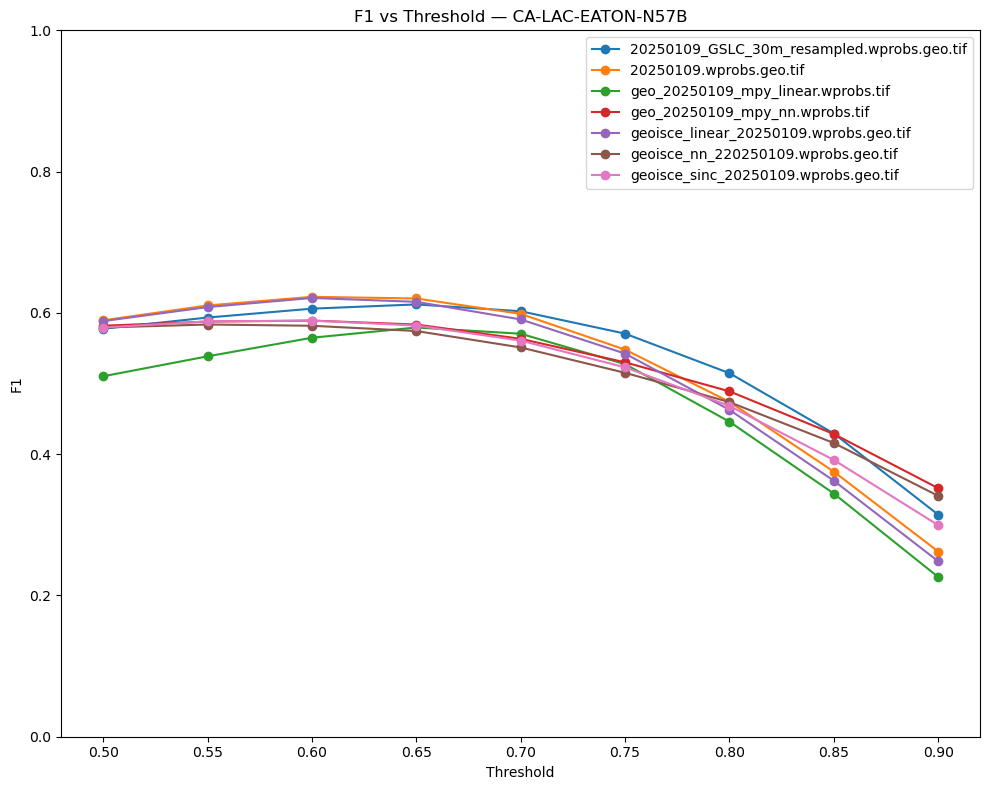

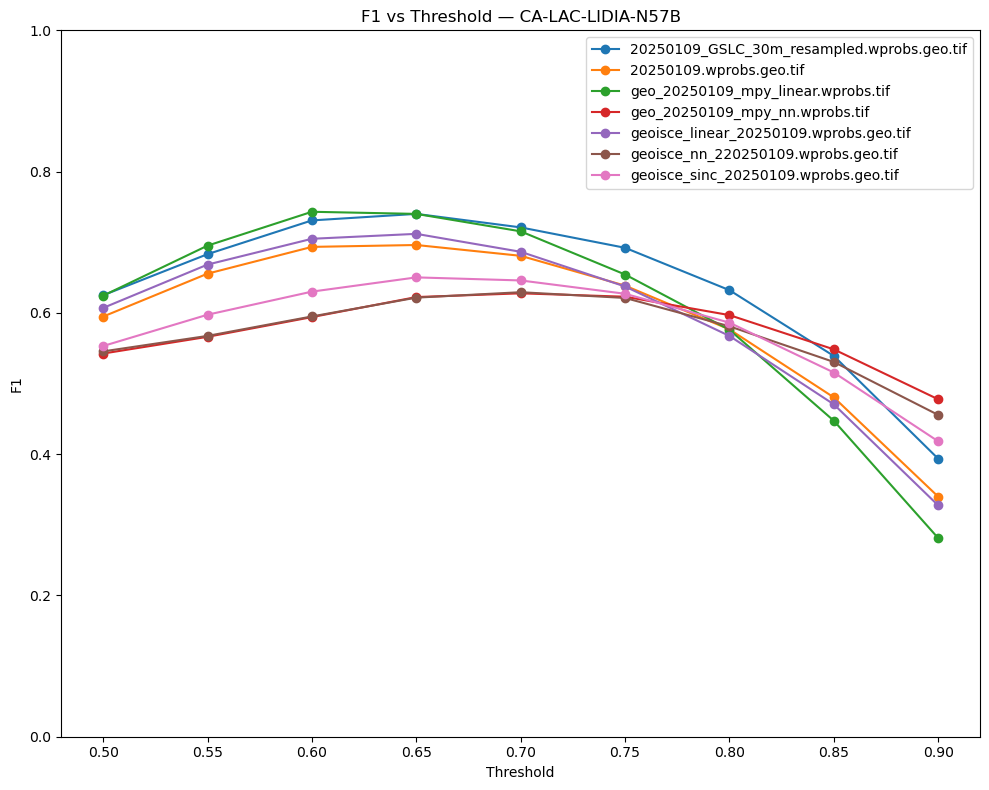

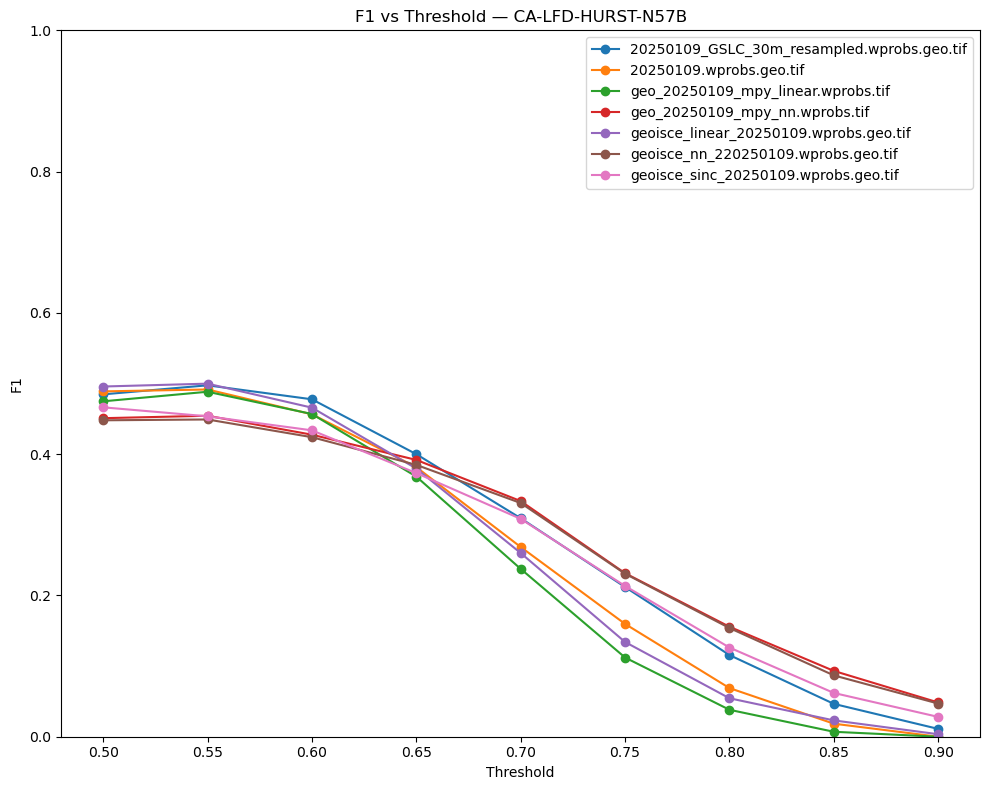

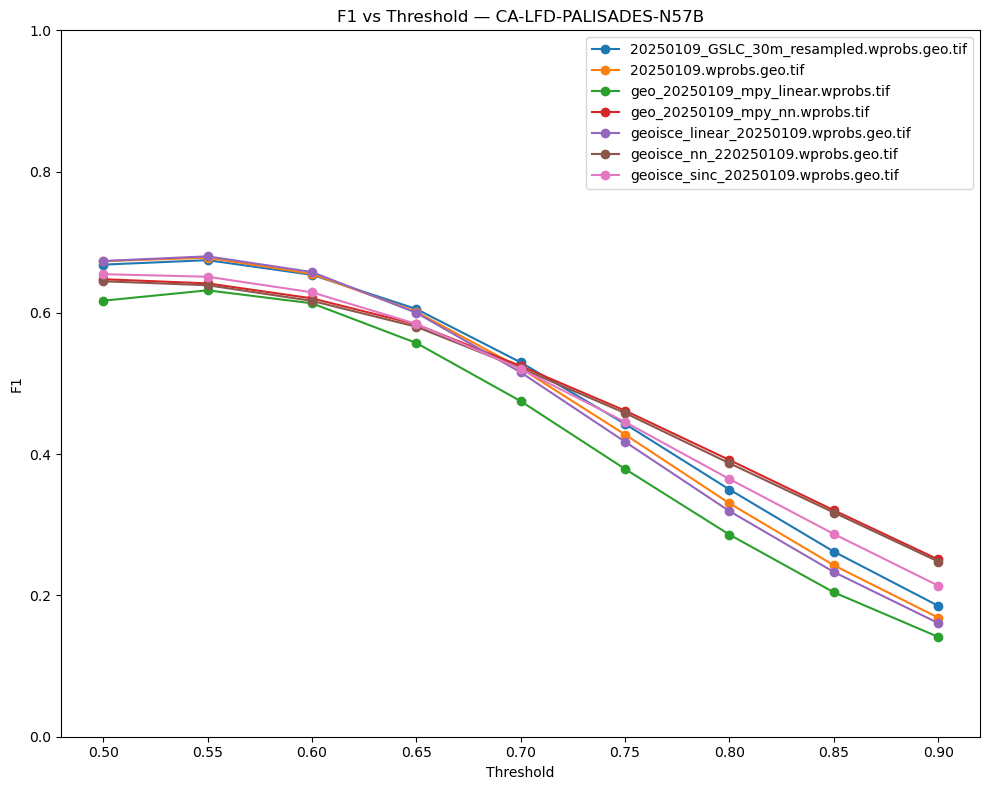

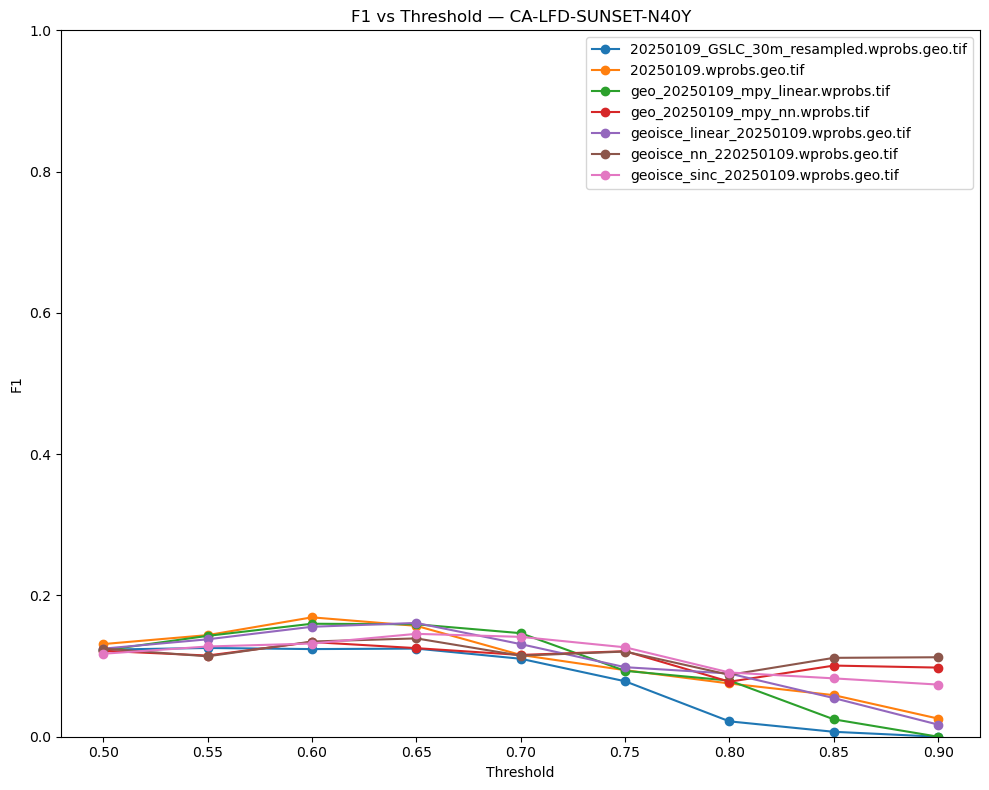

In [20]:
if df_metrics.empty:
    raise ValueError("No results produced. Check CRS alignment, nodata_value, and min_pixels.")

for mission, dfg in df_metrics.groupby("mission"):
    plt.figure(figsize=(10, 8))
    for raster, dfr in dfg.groupby("raster"):
        dfr = dfr.sort_values("thresh")
        plt.plot(dfr["thresh"], dfr["f1"], marker="o", label=os.path.basename(raster))

    plt.ylim(0, 1)
    plt.xlabel("Threshold")
    plt.ylabel("F1")
    plt.title(f"F1 vs Threshold — {mission}")
    plt.legend()
    plt.tight_layout()
    plt.show()

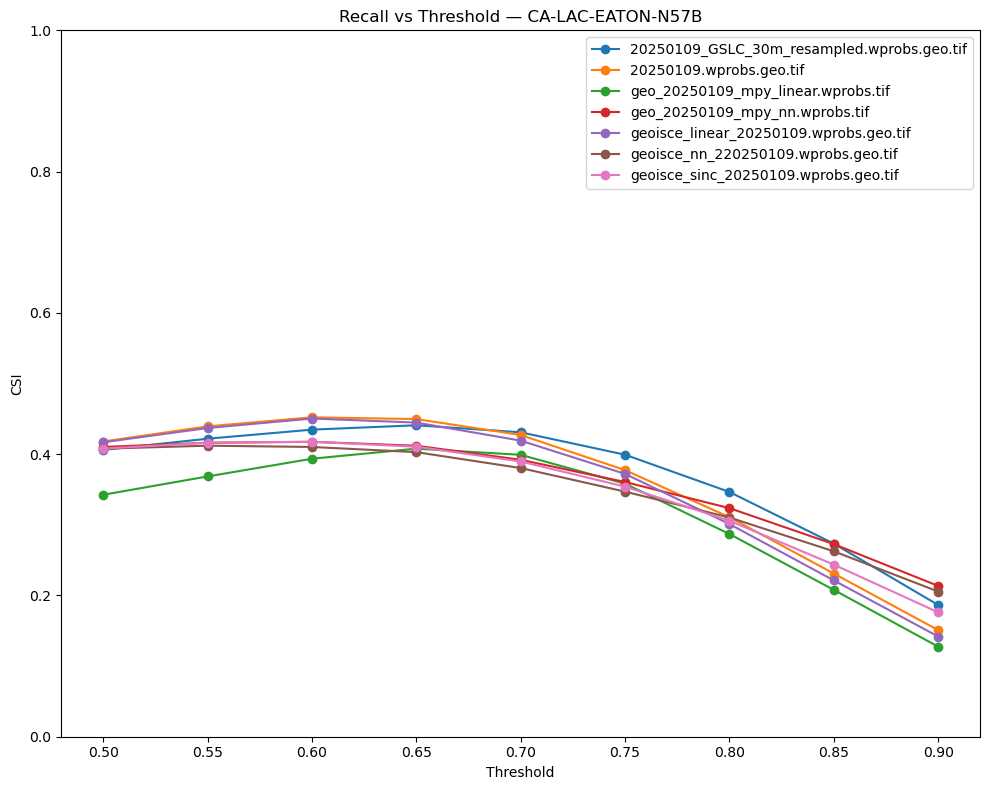

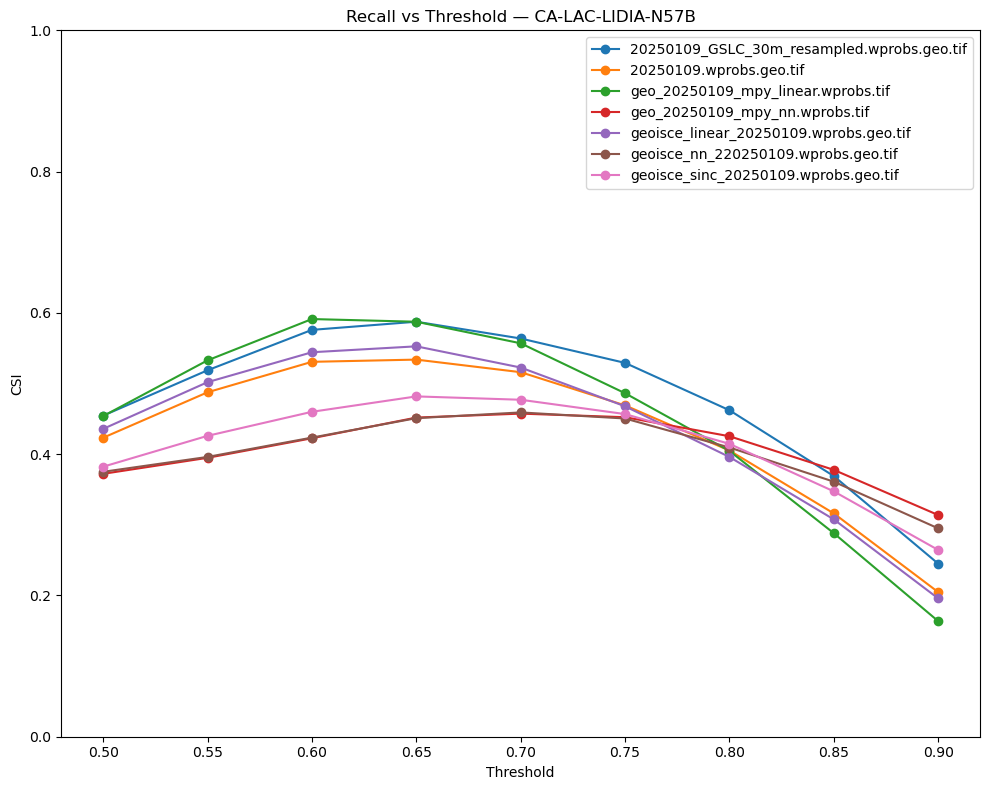

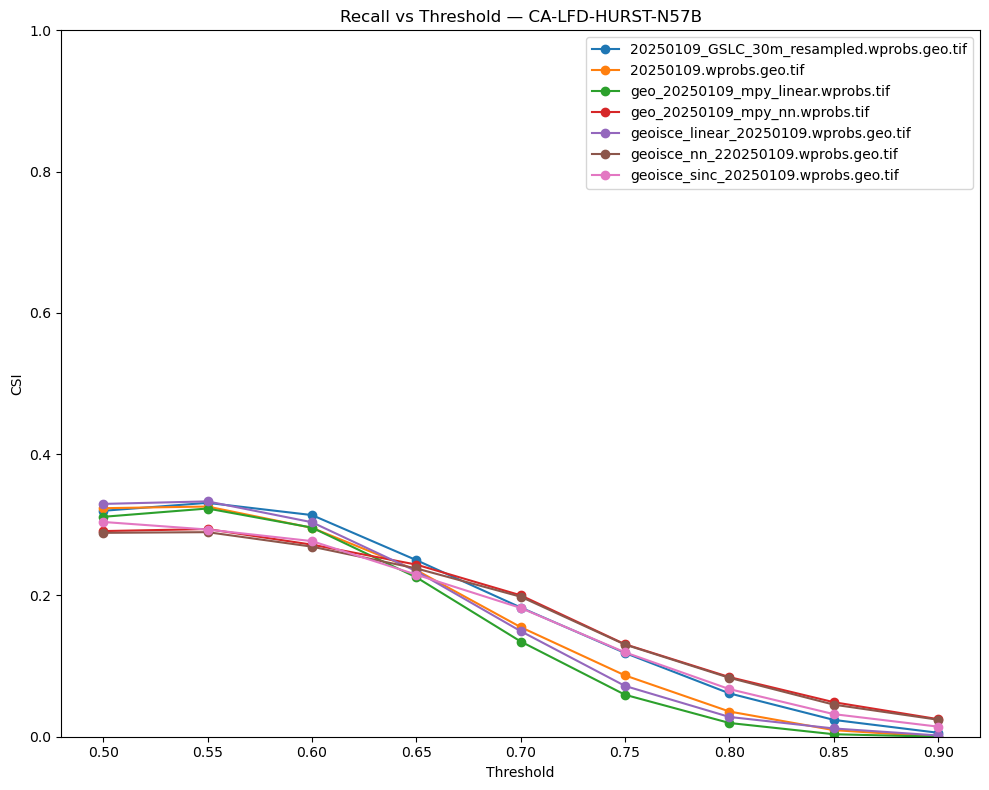

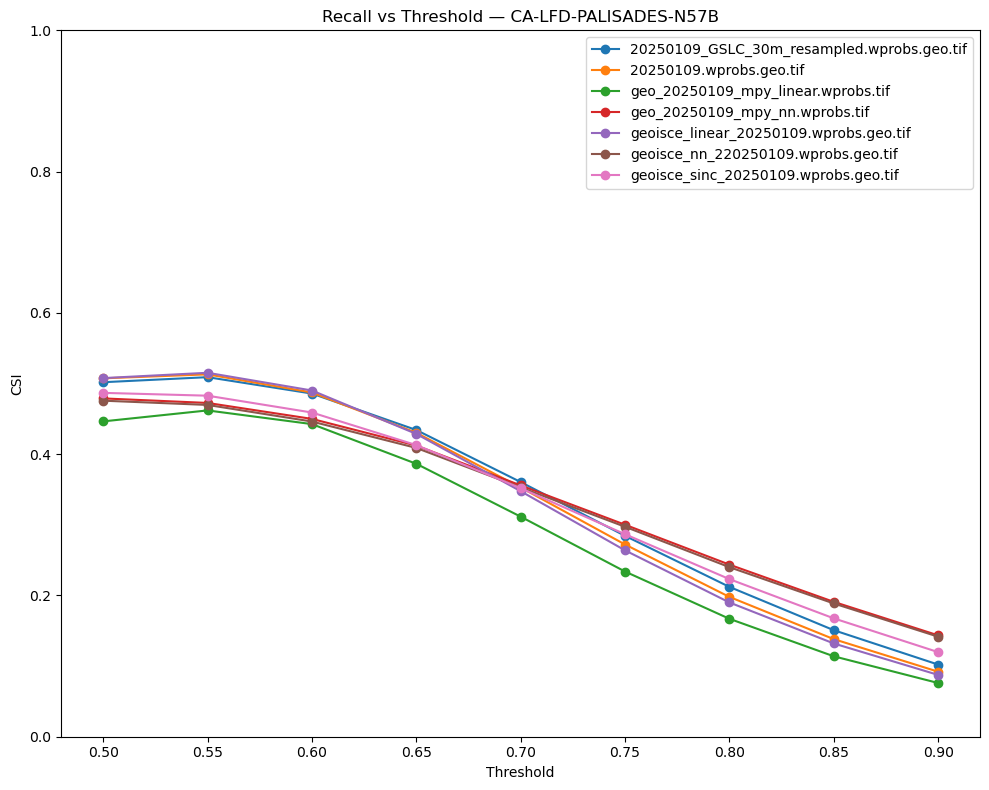

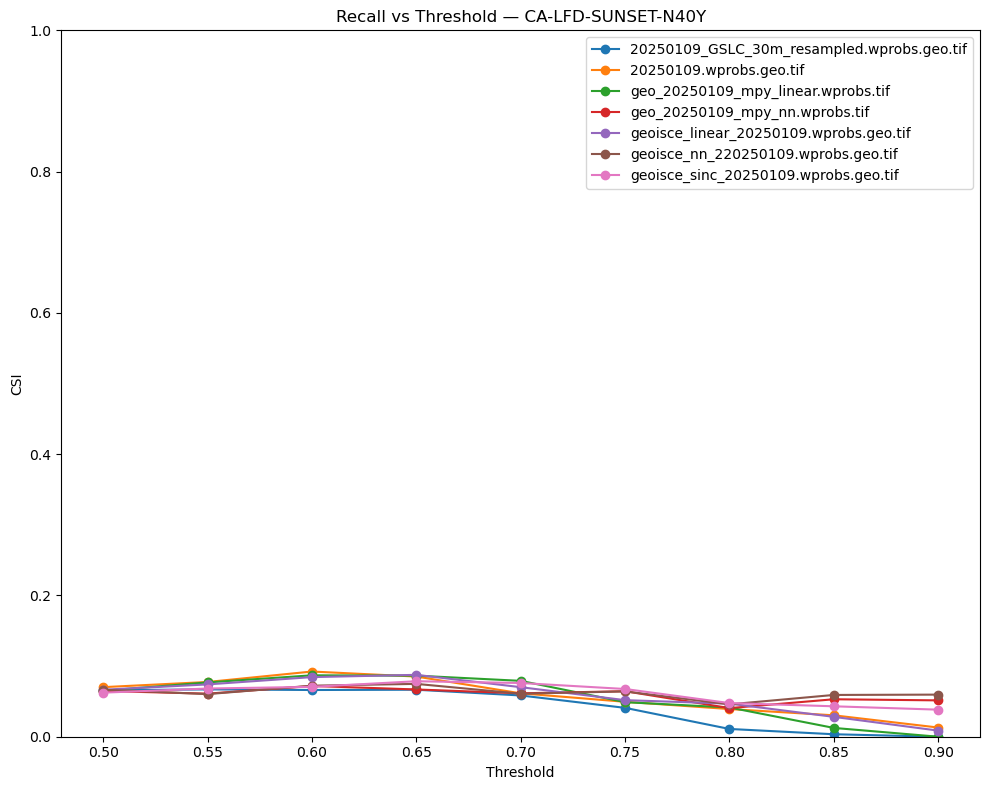

In [18]:
if df_metrics.empty:
    raise ValueError("No results produced. Check CRS alignment, nodata_value, and min_pixels.")

for mission, dfg in df_metrics.groupby("mission"):
    plt.figure(figsize=(10, 8))
    for raster, dfr in dfg.groupby("raster"):
        dfr = dfr.sort_values("thresh")
        plt.plot(dfr["thresh"], dfr["csi"], marker="o", label=os.path.basename(raster))

    plt.ylim(0, 1)
    plt.xlabel("Threshold")
    plt.ylabel("CSI")
    plt.title(f"Recall vs Threshold — {mission}")
    plt.legend()
    plt.tight_layout()
    plt.show()